<a href="https://colab.research.google.com/github/NicolleTovar/INTELIGENCIA-ARTIFICIAL/blob/main/VIVIENDAS_BOGOTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El archivo 'inmuebles_bogota.csv' no fue encontrado en Colab. Por favor, selecciónalo para subirlo:


Saving inmuebles_bogota.csv to inmuebles_bogota.csv
Dimensiones iniciales del conjunto de datos: (9520, 8)
Muestras de entrenamiento: 7525 | Muestras de prueba: 1882

              TABLA COMPARATIVA DE RENDIMIENTO
          Métrica de Evaluación Regresión Lineal Árbol de Decisión
     MAE (Error Absoluto Medio) $182,802,835 COP  $165,602,550 COP
RMSE (Raíz de Error Cuadrático) $358,174,482 COP  $405,189,858 COP
 R² (Coeficiente Determinación)           0.6353            0.5333



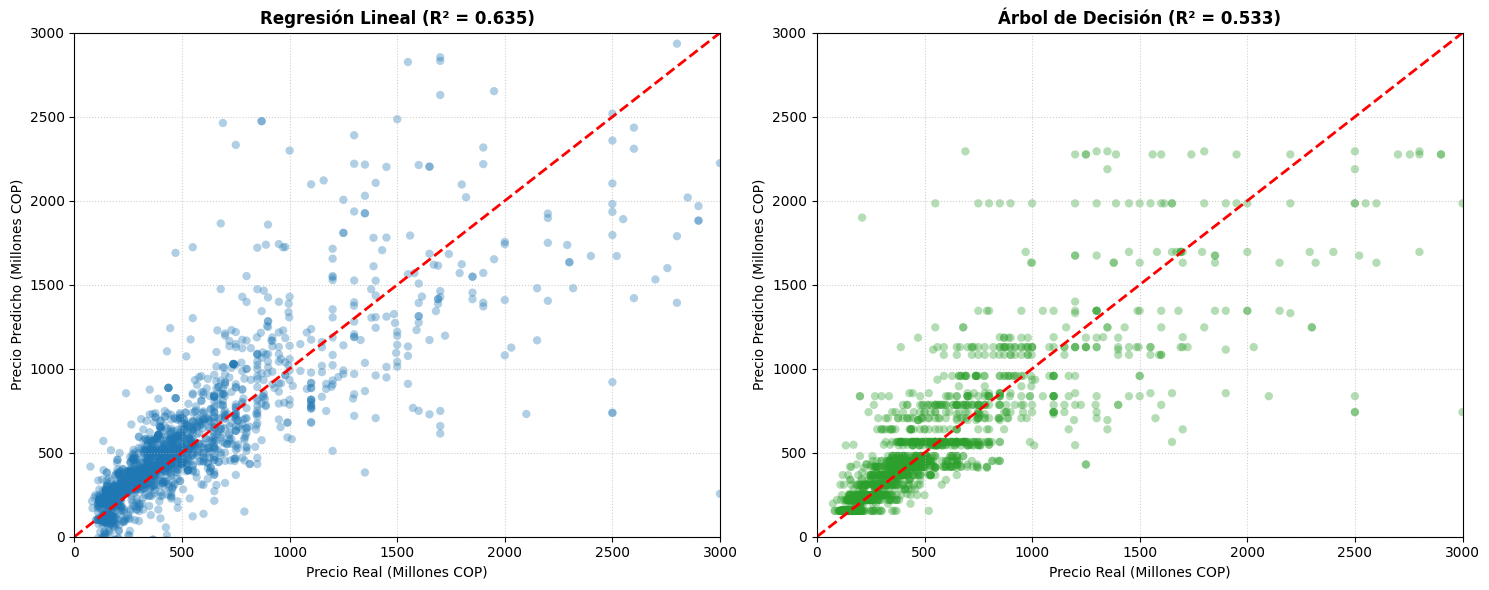

In [4]:
# Importo la librería os para verificar si el archivo del dataset ya existe en el directorio de trabajo.
import os

# Importo files desde google.colab para habilitar la subida interactiva del dataset si no se encuentra en el entorno.
from google.colab import files

# Verifico si el archivo 'inmuebles_bogota.csv' ya está presente en el sistema de archivos de la máquina virtual.
if not os.path.exists('inmuebles_bogota.csv'):
    # Imprimo un mensaje instructivo avisando que se solicitará la carga del archivo.
    print("El archivo 'inmuebles_bogota.csv' no fue encontrado en Colab. Por favor, selecciónalo para subirlo:")
    # Abro la ventana de diálogo para que puedas seleccionar 'inmuebles_bogota.csv' desde tu computador.
    subida = files.upload()

# Importo pandas para organizar los datos de los inmuebles en un DataFrame tabular y realizar transformaciones.
import pandas as pd

# Importo numpy para operaciones numéricas avanzadas y cálculo de raíces cuadradas para las métricas de error.
import numpy as np

# Importo matplotlib.pyplot para trazar las gráficas diagnósticas de predicciones versus valores observados.
import matplotlib.pyplot as plt

# Importo seaborn para aplicar un formato estético más limpio y profesional a las visualizaciones.
import seaborn as sns

# Importo train_test_split para separar de forma aleatoria y representativa los datos en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# Importo LinearRegression para calibrar el modelo paramétrico lineal tradicional mediante mínimos cuadrados.
from sklearn.linear_model import LinearRegression

# Importo DecisionTreeRegressor para construir el árbol de regresión no lineal particionando el espacio de variables.
from sklearn.tree import DecisionTreeRegressor

# Importo las métricas MAE, MSE y R2 para medir la desviación del precio en pesos y la varianza explicada.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Leo el archivo CSV de inmuebles de Bogotá ubicado en el entorno de trabajo y lo cargo en mi variable df.
df = pd.read_csv('inmuebles_bogota.csv')

# Imprimo las dimensiones iniciales del dataset para constatar cuántos registros y columnas tiene disponibles.
print(f"Dimensiones iniciales del conjunto de datos: {df.shape}")

# Remuevo el símbolo monetario '$' de la columna Valor para aislar únicamente la cifra numérica.
df['Precio_Limpio'] = df['Valor'].str.replace('$', '', regex=False)

# Quito los puntos separadores de miles para que el número pueda leerse como una sola cifra continua.
df['Precio_Limpio'] = df['Precio_Limpio'].str.replace('.', '', regex=False)

# Remuevo cualquier espacio en blanco al inicio o al final del texto para no generar fallas al convertir a número.
df['Precio_Limpio'] = df['Precio_Limpio'].str.strip()

# Transformo la columna resultante al tipo float para tener la variable objetivo de precios en pesos colombianos continuos.
df['Precio_COP'] = df['Precio_Limpio'].astype(float)

# Elimino la columna temporal 'Precio_Limpio' para mantener ordenado el DataFrame y optimizar la memoria.
df.drop(columns=['Precio_Limpio'], inplace=True)

# Filtro propiedades con áreas menores o iguales a 10 m² o mayores a 1.200 m² para excluir digitaciones erróneas.
df_filtrado = df[(df['Área'] > 10) & (df['Área'] < 1200)].copy()

# Excluyo inmuebles con más de 12 habitaciones, ya que corresponden a valores atípicos (como registros de 110 habitaciones).
df_filtrado = df_filtrado[df_filtrado['Habitaciones'] <= 12]

# Defino una lista con las tipologías de inmuebles más frecuentes y representativas en la ciudad de Bogotá.
tipos_principales = ['Apartamento', 'Casa', 'Oficina/Consultorio', 'Local']

# Conservo únicamente aquellas filas que coinciden con los tipos de propiedades definidos en la lista principal.
df_modelo = df_filtrado[df_filtrado['Tipo'].isin(tipos_principales)].copy()

# Aplico One-Hot Encoding sobre la columna 'Tipo' con drop_first=True para evitar colinealidad exacta entre dummies.
df_modelo = pd.get_dummies(df_modelo, columns=['Tipo'], drop_first=True)

# Armo la lista de características independientes X juntando las numéricas con las nuevas variables binarias creadas.
columnas_predictores = ['Habitaciones', 'Baños', 'Área'] + [col for col in df_modelo.columns if col.startswith('Tipo_')]

# Extraigo la matriz de características X con los predictores seleccionados.
X = df_modelo[columnas_predictores]

# Extraigo el vector objetivo 'y' con el precio en pesos colombianos de cada predio.
y = df_modelo['Precio_COP']

# Divido los datos reservando 80% para entrenar y 20% para evaluar, con random_state=42 para garantizar reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Imprimo la cantidad de observaciones destinadas al entrenamiento y a la prueba para validar la división.
print(f"Muestras de entrenamiento: {X_train.shape[0]} | Muestras de prueba: {X_test.shape[0]}")

# Instancio el algoritmo de Regresión Lineal en el objeto modelo_lr.
modelo_lr = LinearRegression()

# Ajusto el modelo lineal utilizando los datos de entrenamiento para aprender los coeficientes de ponderación.
modelo_lr.fit(X_train, y_train)

# Genero las estimaciones de precio para las observaciones del conjunto de prueba con el modelo lineal entrenado.
y_pred_lr = modelo_lr.predict(X_test)

# Instancio el modelo de Árbol de Decisión limitando max_depth=6 para controlar la complejidad y prevenir sobreajuste.
modelo_dt = DecisionTreeRegressor(max_depth=6, random_state=42)

# Ajusto el árbol de decisión sobre el conjunto de entrenamiento mediante particiones que reducen la varianza del error.
modelo_dt.fit(X_train, y_train)

# Genero las predicciones de precios para el conjunto de prueba con la estructura de nodos aprendida por el árbol.
y_pred_dt = modelo_dt.predict(X_test)

# Calculo el Error Absoluto Medio (MAE) de la Regresión Lineal en pesos colombianos.
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Calculo la Raíz del Error Cuadrático Medio (RMSE) de la Regresión Lineal para penalizar con fuerza errores grandes.
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculo el coeficiente R2 de la Regresión Lineal para conocer qué porcentaje de la variabilidad del precio logra explicar.
r2_lr = r2_score(y_test, y_pred_lr)

# Calculo el Error Absoluto Medio (MAE) para el Árbol de Decisión sobre el conjunto de prueba.
mae_dt = mean_absolute_error(y_test, y_pred_dt)

# Calculo la Raíz del Error Cuadrático Medio (RMSE) para el Árbol de Decisión.
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

# Calculo el coeficiente R2 del Árbol de Decisión para evaluar el ajuste no lineal logrado.
r2_dt = r2_score(y_test, y_pred_dt)

# Construyo un DataFrame comparativo con los valores formateados en pesos para evaluar ambos métodos lado a lado.
tabla_resultados = pd.DataFrame({
    'Métrica de Evaluación': ['MAE (Error Absoluto Medio)', 'RMSE (Raíz de Error Cuadrático)', 'R² (Coeficiente Determinación)'],
    'Regresión Lineal': [f"${mae_lr:,.0f} COP", f"${rmse_lr:,.0f} COP", f"{r2_lr:.4f}"],
    'Árbol de Decisión': [f"${mae_dt:,.0f} COP", f"${rmse_dt:,.0f} COP", f"{r2_dt:.4f}"]
})

# Muestro la tabla comparativa en la consola de salida sin incluir índices numéricos.
print("\n" + "="*70)
print("              TABLA COMPARATIVA DE RENDIMIENTO")
print("="*70)
print(tabla_resultados.to_string(index=False))
print("="*70 + "\n")

# Creo una figura de visualización con dos subgráficos horizontales de tamaño 15x6 pulgadas.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafico la dispersión entre precios reales y predichos por la Regresión Lineal normalizados a millones de COP.
axes[0].scatter(y_test / 1e6, y_pred_lr / 1e6, alpha=0.35, color='#1f77b4', edgecolors='none')

# Trazo la línea diagonal discontinua de 45 grados en color rojo que representa la predicción perfecta ideal (y = x).
axes[0].plot([0, 3000], [0, 3000], color='red', linestyle='--', linewidth=2)

# Asigno el título al primer gráfico indicando el nombre del modelo y su métrica R2 obtenida.
axes[0].set_title(f'Regresión Lineal (R² = {r2_lr:.3f})', fontsize=12, fontweight='bold')

# Etiqueto el eje horizontal indicando que corresponde a los valores reales observados en millones de COP.
axes[0].set_xlabel('Precio Real (Millones COP)', fontsize=10)

# Etiqueto el eje vertical indicando que corresponde a las predicciones calculadas en millones de COP.
axes[0].set_ylabel('Precio Predicho (Millones COP)', fontsize=10)

# Activo la cuadrícula punteada en el primer gráfico para facilitar la lectura de coordenadas.
axes[0].grid(True, linestyle=':', alpha=0.6)

# Establezco los límites de los ejes entre 0 y 3.000 millones para centrar la vista en el rango más denso de Bogotá.
axes[0].set_xlim(0, 3000)
axes[0].set_ylim(0, 3000)

# Grafico la dispersión entre precios reales y predichos por el Árbol de Decisión en millones de COP.
axes[1].scatter(y_test / 1e6, y_pred_dt / 1e6, alpha=0.35, color='#2ca02c', edgecolors='none')

# Trazo la línea diagonal roja de predicción exacta en el segundo panel.
axes[1].plot([0, 3000], [0, 3000], color='red', linestyle='--', linewidth=2)

# Asigno el título al segundo gráfico destacando el R2 del árbol de decisión.
axes[1].set_title(f'Árbol de Decisión (R² = {r2_dt:.3f})', fontsize=12, fontweight='bold')

# Etiqueto el eje horizontal del segundo gráfico en millones de COP.
axes[1].set_xlabel('Precio Real (Millones COP)', fontsize=10)

# Etiqueto el eje vertical del segundo gráfico en millones de COP.
axes[1].set_ylabel('Precio Predicho (Millones COP)', fontsize=10)

# Activo la cuadrícula en el panel del árbol de decisión con ligera transparencia.
axes[1].grid(True, linestyle=':', alpha=0.6)

# Establezco la misma escala en los ejes (0 a 3.000 millones) para garantizar una comparación equitativa.
axes[1].set_xlim(0, 3000)
axes[1].set_ylim(0, 3000)

# Aplico tight_layout para asegurar que los títulos y ejes no se superpongan visualmente.
plt.tight_layout()

# Despliego la figura con las dos gráficas de dispersión en el cuaderno de Google Colab.
plt.show()